# Energy Consumption & Demand Analysis

## Exploratory Data Analysis and Demand Analysis

This notebook performs deeper analysis of household electricity consumption using the cleaned dataset prepared in Notebook 1.

### Objectives
- Analyze energy consumption patterns
- Identify peak-demand periods
- Study daily, monthly, and hourly trends
- Compare weekday and weekend demand
- Analyze relationships between electrical variables
- Identify high-demand periods
- Prepare data for predictive modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is working!")

Environment is working!


## 1. Loading Processed Dataset

In [2]:
file_path = "data/processed/energy_consumption_clean.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["Datetime"]
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 2049280
Columns: 17


In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,DayOfWeek,Is_Weekend,Energy_kWh
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16,17,5,True,0.070267
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16,17,5,True,0.089333
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16,17,5,True,0.089567
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16,17,5,True,0.089800
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16,17,5,True,0.061100


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 17 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Datetime               datetime64[us]
 10  Year                   int64         
 11  Month                  int64         
 12  Day                    int64         
 13  Hour                   int64         
 14  DayOfWeek              int64         
 15  Is_Weekend             bool          
 16  Energy_kWh             float64       
dtypes: bool(1), datetime64[us](1), float64(8), int64(5), str(2)
memory usage: 25

In [5]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,DayOfWeek,Energy_kWh
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2049280,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-02 00:59:44.397739,2.008425e+03,6.454433e+00,1.571245e+01,1.150391e+01,2.989276e+00,1.819358e-02
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00,2.006000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.266667e-03
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-10 05:37:45,2.007000e+03,3.000000e+00,8.000000e+00,5.000000e+00,1.000000e+00,5.133333e-03
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-11-30 01:22:30,2.008000e+03,6.000000e+00,1.600000e+01,1.200000e+01,3.000000e+00,1.003333e-02
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-11-23 20:31:15,2.009000e+03,9.000000e+00,2.300000e+01,1.800000e+01,5.000000e+00,2.546667e-02
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00,2.010000e+03,1.200000e+01,3.100000e+01,2.300000e+01,6.000000e+00,1.853667e-01
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN,1.124388e+00,3.423209e+00,8.801670e+00,6.925189e+00,1.997633e+00,1.762157e-02


In [6]:
print("Start date:", df["Datetime"].min())
print("End date:", df["Datetime"].max())

Start date: 2006-12-16 17:24:00
End date: 2010-11-26 21:02:00


In [7]:
df[
    [
        "Datetime",
        "Global_active_power",
        "Energy_kWh",
        "Voltage",
        "Global_intensity",
        "Hour",
        "DayOfWeek",
        "Is_Weekend"
    ]
].head(10)

,Datetime,Global_active_power,Energy_kWh,Voltage,Global_intensity,Hour,DayOfWeek,Is_Weekend
0,2006-12-16 17:24:00,4.216,0.070267,234.84,18.4,17,5,True
1,2006-12-16 17:25:00,5.360,0.089333,233.63,23.0,17,5,True
2,2006-12-16 17:26:00,5.374,0.089567,233.29,23.0,17,5,True
3,2006-12-16 17:27:00,5.388,0.089800,233.74,23.0,17,5,True
4,2006-12-16 17:28:00,3.666,0.061100,235.68,15.8,17,5,True
5,2006-12-16 17:29:00,3.520,0.058667,235.02,15.0,17,5,True
6,2006-12-16 17:30:00,3.702,0.061700,235.09,15.8,17,5,True
7,2006-12-16 17:31:00,3.700,0.061667,235.22,15.8,17,5,True
8,2006-12-16 17:32:00,3.668,0.061133,233.99,15.8,17,5,True
9,2006-12-16 17:33:00,3.662,0.061033,233.86,15.8,17,5,True


In [8]:
#daily consumption

daily_energy = (
    df.set_index("Datetime")["Energy_kWh"]
    .resample("D")
    .sum()
    .reset_index()
)

daily_energy.head()

,Datetime,Energy_kWh
0,2006-12-16,20.152933
1,2006-12-17,56.507667
2,2006-12-18,36.730433
3,2006-12-19,27.769900
4,2006-12-20,37.095800


In [9]:
#Top 10 Highest-Consumption Days

top_10_days = daily_energy.nlargest(10, "Energy_kWh")

top_10_days

,Datetime,Energy_kWh
7,2006-12-23,79.556433
49,2007-02-03,67.162033
10,2006-12-26,65.568500
64,2007-02-18,63.829367
50,2007-02-04,59.932333
57,2007-02-11,59.520467
105,2007-03-31,58.491833
15,2006-12-31,58.236600
85,2007-03-11,58.010600
36,2007-01-21,56.787700


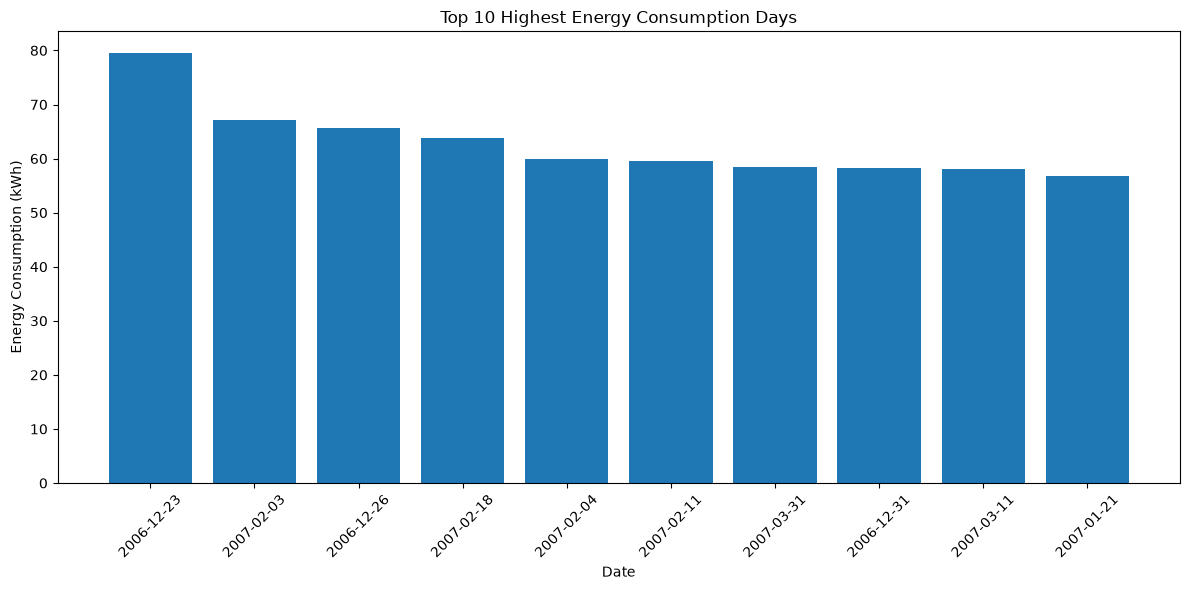

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_days["Datetime"].dt.strftime("%Y-%m-%d"),
    top_10_days["Energy_kWh"]
)

plt.title("Top 10 Highest Energy Consumption Days")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
#average demand for each hour

hourly_demand = (
    df.groupby("Hour")["Global_active_power"]
    .mean()
    .reset_index()
)

hourly_demand

,Hour,Global_active_power
0,0,0.659434
1,1,0.539325
2,2,0.480621
3,3,0.444866
4,4,0.443847
5,5,0.453674
6,6,0.791600
7,7,1.502246
8,8,1.461016
9,9,1.331645


In [12]:
#peak demand hour

peak_hour = hourly_demand.loc[
    hourly_demand["Global_active_power"].idxmax()
]

peak_hour

Hour                   20.000000
Global_active_power     1.899064
Name: 20, dtype: float64

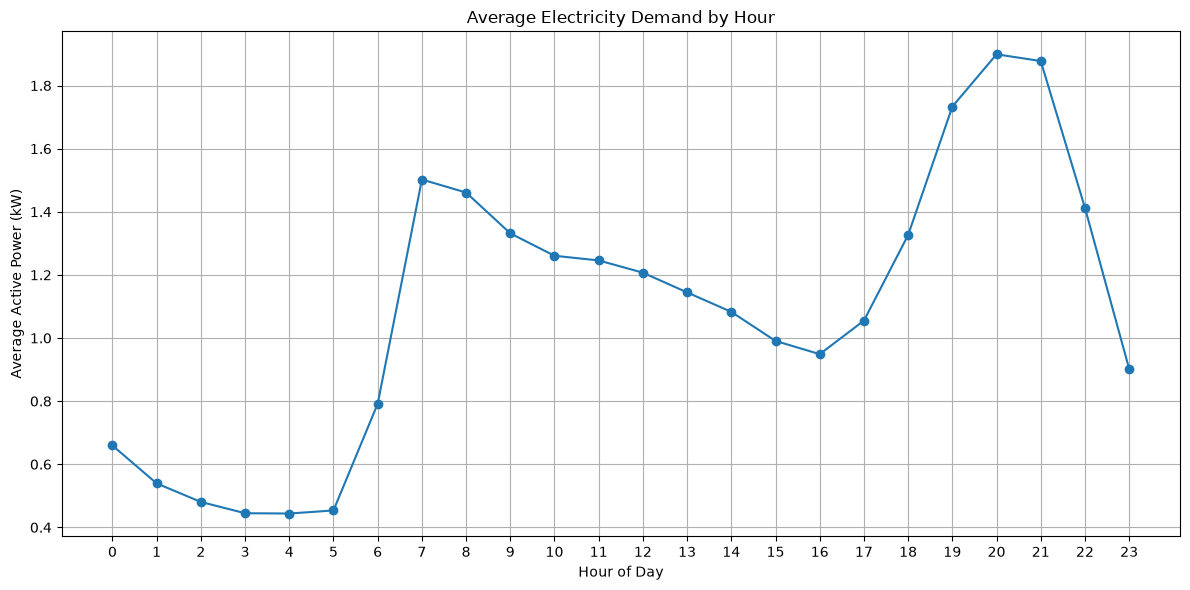

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_demand["Hour"],
    hourly_demand["Global_active_power"],
    marker="o"
)

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Active Power (kW)")
plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Weekday vs Weekend Demand

In [14]:
#average demand

weekday_weekend = (
    df.groupby("Is_Weekend")["Global_active_power"]
    .mean()
    .reset_index()
)

weekday_weekend["Day_Type"] = weekday_weekend["Is_Weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

weekday_weekend

,Is_Weekend,Global_active_power,Day_Type
0,False,1.035472,Weekday
1,True,1.234232,Weekend


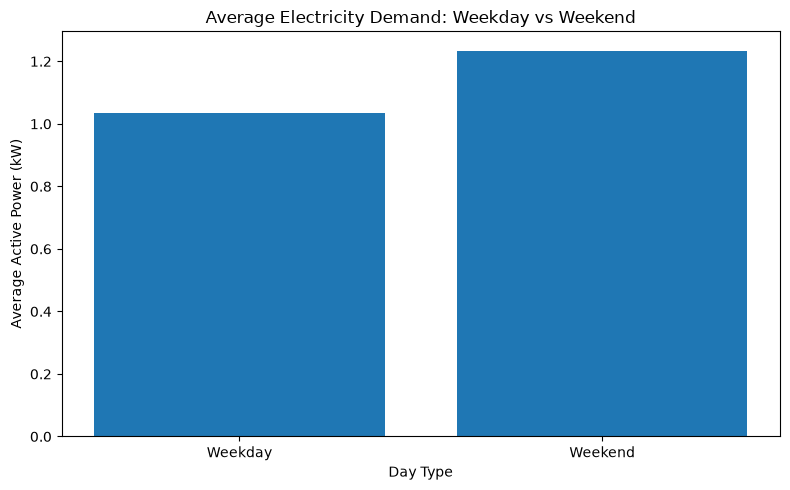

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    weekday_weekend["Day_Type"],
    weekday_weekend["Global_active_power"]
)

plt.title("Average Electricity Demand: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Active Power (kW)")

plt.tight_layout()
plt.show()

In [16]:
weekday_demand = weekday_weekend.loc[
    weekday_weekend["Day_Type"] == "Weekday",
    "Global_active_power"
].iloc[0]

weekend_demand = weekday_weekend.loc[
    weekday_weekend["Day_Type"] == "Weekend",
    "Global_active_power"
].iloc[0]

difference = weekend_demand - weekday_demand

print("Weekday average demand:", round(weekday_demand, 3), "kW")
print("Weekend average demand:", round(weekend_demand, 3), "kW")
print("Weekend - Weekday difference:", round(difference, 3), "kW")

Weekday average demand: 1.035 kW
Weekend average demand: 1.234 kW
Weekend - Weekday difference: 0.199 kW


Monthly Consumption Analysis

In [17]:
#monthly consumption

monthly_energy = (
    df.set_index("Datetime")["Energy_kWh"]
    .resample("MS")
    .sum()
    .reset_index()
)

monthly_energy.head()

,Datetime,Energy_kWh
0,2006-12-01,696.888033
1,2007-01-01,1150.197700
2,2007-02-01,941.481433
3,2007-03-01,981.036533
4,2007-04-01,586.357767


In [18]:
#highest and lowest consumption months

highest_month = monthly_energy.loc[
    monthly_energy["Energy_kWh"].idxmax()
]

lowest_month = monthly_energy.loc[
    monthly_energy["Energy_kWh"].idxmin()
]

print("Highest consumption month:")
print(highest_month)

print("\nLowest consumption month:")
print(lowest_month)

Highest consumption month:
Datetime      2007-12-01 00:00:00
Energy_kWh              1210.0695
Name: 12, dtype: object

Lowest consumption month:
Datetime      2008-08-01 00:00:00
Energy_kWh                205.698
Name: 20, dtype: object


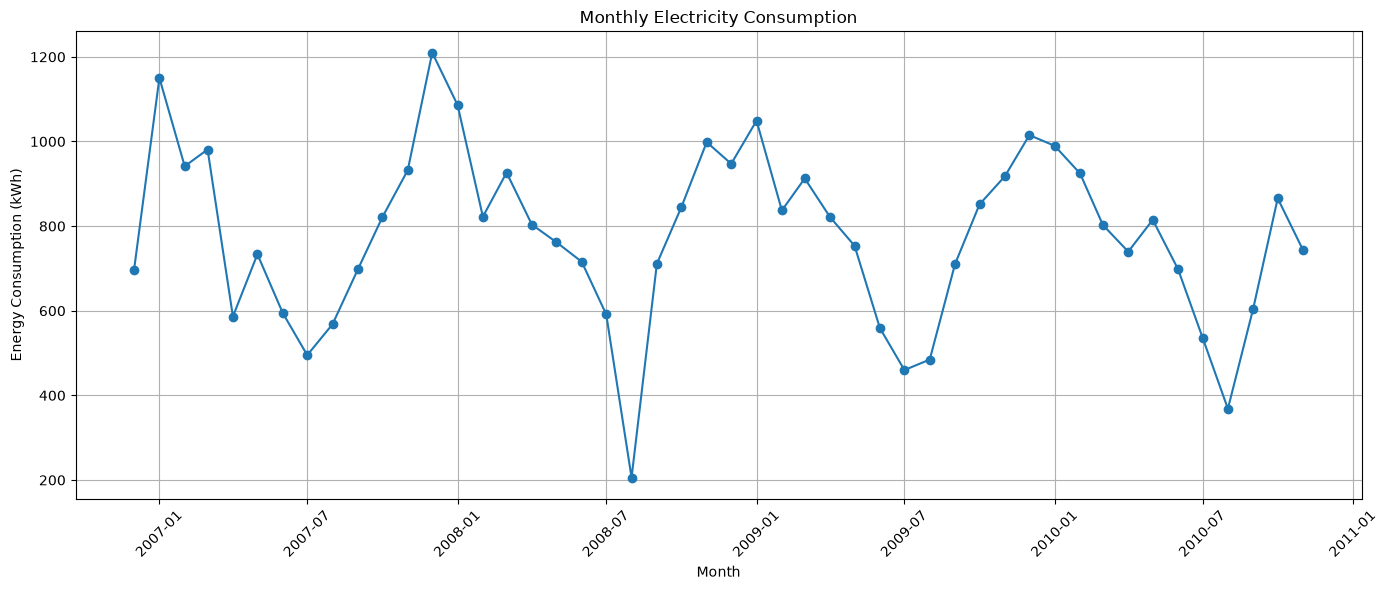

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_energy["Datetime"],
    monthly_energy["Energy_kWh"],
    marker="o"
)

plt.title("Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

Appliance/Sub-metering Analysis

In [20]:
#average usage

submetering = df[
    [
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
].mean()

submetering

Sub_metering_1    1.121923
Sub_metering_2    1.298520
Sub_metering_3    6.458447
dtype: float64

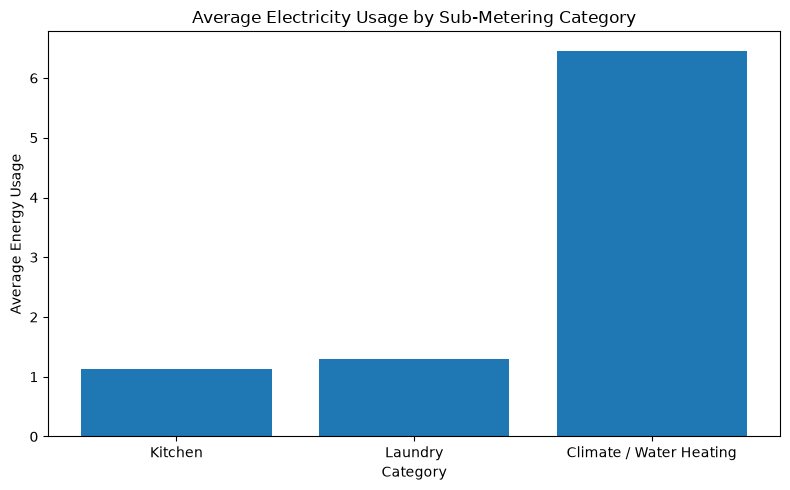

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Kitchen", "Laundry", "Climate / Water Heating"],
    submetering.values
)

plt.title("Average Electricity Usage by Sub-Metering Category")
plt.xlabel("Category")
plt.ylabel("Average Energy Usage")

plt.tight_layout()
plt.show()

In [22]:
#highest category

highest_category = submetering.idxmax()

print("Highest average sub-metering category:", highest_category)
print("Average value:", round(submetering.max(), 3))

Highest average sub-metering category: Sub_metering_3
Average value: 6.458


Correlation Analysis

In [23]:
#the correlation matrix

correlation = df[
    [
        "Global_active_power",
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
].corr()

correlation

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000


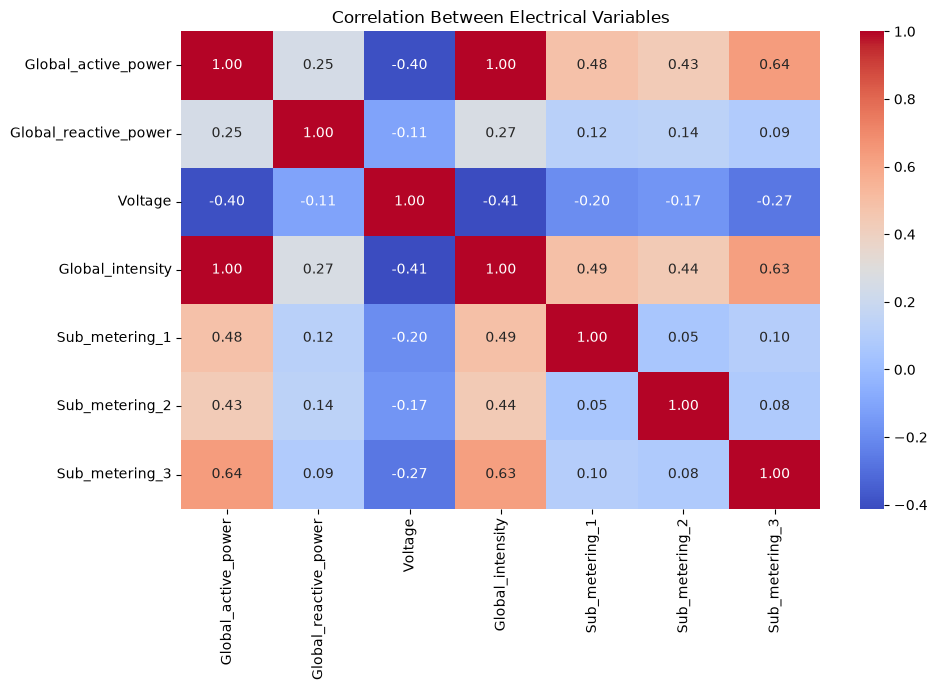

In [24]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Electrical Variables")

plt.tight_layout()
plt.show()

In [25]:
#most correlated with demand

target_correlation = (
    correlation["Global_active_power"]
    .drop("Global_active_power")
    .sort_values(ascending=False)
)

target_correlation

Global_intensity         0.998889
Sub_metering_3           0.638555
Sub_metering_1           0.484401
Sub_metering_2           0.434569
Global_reactive_power    0.247017
Voltage                 -0.399762
Name: Global_active_power, dtype: float64

High-Demand Periods

In [26]:
#high-demand threshold

Q1 = df["Global_active_power"].quantile(0.25)
Q3 = df["Global_active_power"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print("Q1:", round(Q1, 3))
print("Q3:", round(Q3, 3))
print("IQR:", round(IQR, 3))
print("High-demand threshold:", round(upper_limit, 3), "kW")

Q1: 0.308
Q3: 1.528
IQR: 1.22
High-demand threshold: 3.358 kW


In [27]:
#high-demand observations

high_demand = df[
    df["Global_active_power"] > upper_limit
].copy()

print("High-demand observations:", len(high_demand))
print(
    "Percentage of observations:",
    round(len(high_demand) / len(df) * 100, 2),
    "%"
)

High-demand observations: 94907
Percentage of observations: 4.63 %


In [28]:
#highest-demand observations

highest_demand = (
    df.nlargest(10, "Global_active_power")
    [
        [
            "Datetime",
            "Global_active_power",
            "Global_intensity",
            "Voltage",
            "Hour",
            "Is_Weekend"
        ]
    ]
)

highest_demand

,Datetime,Global_active_power,Global_intensity,Voltage,Hour,Is_Weekend
1146410,2009-02-22 17:09:00,11.122,48.4,229.78,17,True
112442,2007-03-04 19:34:00,10.670,46.4,230.20,19,True
112441,2007-03-04 19:33:00,10.650,46.4,229.97,19,True
1146409,2009-02-22 17:08:00,10.536,45.8,230.24,17,True
1025776,2008-11-30 20:19:00,10.348,44.6,231.60,20,True
964213,2008-10-19 01:24:00,10.290,44.6,230.90,1,True
582264,2008-01-27 19:24:00,10.162,44.2,229.16,19,True
112440,2007-03-04 19:32:00,10.154,44.4,229.72,19,True
1025774,2008-11-30 20:17:00,10.074,43.4,231.41,20,True
964214,2008-10-19 01:25:00,10.064,43.4,231.48,1,True


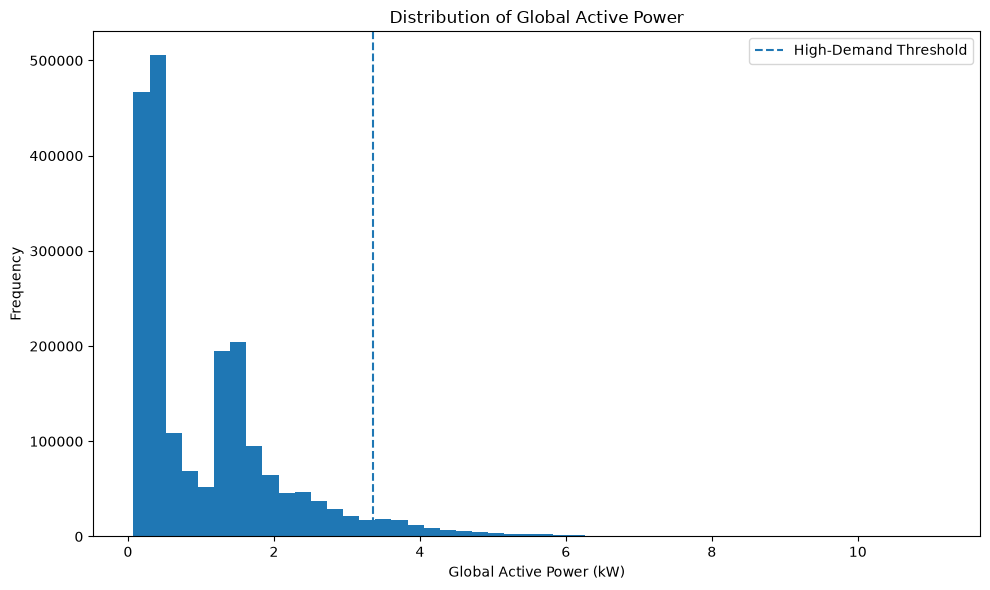

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Global_active_power"],
    bins=50
)

plt.axvline(
    upper_limit,
    linestyle="--",
    label="High-Demand Threshold"
)

plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
hourly_data = (
    df.set_index("Datetime")
    .resample("h")["Global_active_power"]
    .mean()
    .reset_index()
)

hourly_data.head()

,Datetime,Global_active_power
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [31]:
#time features

hourly_data["Hour"] = hourly_data["Datetime"].dt.hour
hourly_data["DayOfWeek"] = hourly_data["Datetime"].dt.dayofweek
hourly_data["Month"] = hourly_data["Datetime"].dt.month
hourly_data["Day"] = hourly_data["Datetime"].dt.day
hourly_data["Is_Weekend"] = (
    hourly_data["DayOfWeek"] >= 5
).astype(int)

hourly_data.head()

,Datetime,Global_active_power,Hour,DayOfWeek,Month,Day,Is_Weekend
0,2006-12-16 17:00:00,4.222889,17,5,12,16,1
1,2006-12-16 18:00:00,3.632200,18,5,12,16,1
2,2006-12-16 19:00:00,3.400233,19,5,12,16,1
3,2006-12-16 20:00:00,3.268567,20,5,12,16,1
4,2006-12-16 21:00:00,3.056467,21,5,12,16,1


In [ ]:
#A lag feature means using previous consumption to help predict current consumption.


hourly_data["Lag_1"] = (
    hourly_data["Global_active_power"].shift(1) #consumption 1 hour ago
)

hourly_data["Lag_24"] = (
    hourly_data["Global_active_power"].shift(24) #consumption 24 hours ago
)

hourly_data["Lag_168"] = (
    hourly_data["Global_active_power"].shift(168) #consumption 168 hours ago = 7 days ago

)

In [34]:
#rolling averages


hourly_data["Rolling_24h"] = (
    hourly_data["Global_active_power"]
    .shift(1)
    .rolling(24)
    .mean()
)

hourly_data["Rolling_168h"] = (
    hourly_data["Global_active_power"]
    .shift(1)
    .rolling(168)
    .mean()
)

In [35]:
#Remove missing values

hourly_data = hourly_data.dropna().reset_index(drop=True)

print("Rows:", len(hourly_data))
print("Columns:", len(hourly_data.columns))

hourly_data.head()

Rows: 32656
Columns: 12


,Datetime,Global_active_power,Hour,DayOfWeek,Month,Day,Is_Weekend,Lag_1,Lag_24,Lag_168,Rolling_24h,Rolling_168h
0,2006-12-23 17:00:00,5.452533,17,5,12,23,1,4.349100,1.496800,4.222889,2.934890,1.763946
1,2006-12-23 18:00:00,3.879400,18,5,12,23,1,5.452533,2.686967,3.632200,3.099713,1.771265
2,2006-12-23 19:00:00,4.117833,19,5,12,23,1,3.879400,3.938167,3.400233,3.149397,1.772736
3,2006-12-23 20:00:00,4.181400,20,5,12,23,1,4.117833,3.536067,3.268567,3.156883,1.777008
4,2006-12-23 21:00:00,3.288433,21,5,12,23,1,4.181400,4.548667,3.056467,3.183772,1.782441


Prepare Data for Machine Learning


In [36]:
#Prepare Data for Machine Learning

features = [
    "Hour",
    "DayOfWeek",
    "Month",
    "Day",
    "Is_Weekend",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "Rolling_24h",
    "Rolling_168h"
]

X = hourly_data[features]
y = hourly_data["Global_active_power"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (32656, 10)
Target: (32656,)


In [37]:
#a time-based train/test split

split_index = int(len(hourly_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining period:")
print(hourly_data["Datetime"].iloc[0])
print("to")
print(hourly_data["Datetime"].iloc[split_index - 1])

print("\nTesting period:")
print(hourly_data["Datetime"].iloc[split_index])
print("to")
print(hourly_data["Datetime"].iloc[-1])

Training rows: 26124
Testing rows: 6532

Training period:
2006-12-23 17:00:00
to
2010-01-27 18:00:00

Testing period:
2010-01-27 19:00:00
to
2010-11-26 21:00:00


In [38]:
#checking the split


print("Training target mean:", round(y_train.mean(), 3))
print("Testing target mean:", round(y_test.mean(), 3))

print("\nTraining target range:")
print(round(y_train.min(), 3), "to", round(y_train.max(), 3))

print("\nTesting target range:")
print(round(y_test.min(), 3), "to", round(y_test.max(), 3))

Training target mean: 1.109
Testing target mean: 1.03

Training target range:
0.124 to 6.561

Testing target range:
0.195 to 5.627


In [39]:
#Linear Regression

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [40]:
#predictions


linear_predictions = linear_model.predict(X_test)

print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[2.61567198 2.80620296 2.81938898 3.1524926  2.41924987 1.35473597
 1.25292613 1.20673925 1.20642807 0.4357034 ]


Evaluate the model

MAE → average prediction error
RMSE → penalizes larger errors more strongly
R² → how much variation the model explains


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 0.373
RMSE: 0.5243
R²  : 0.522


MAE = 0.37 kW → average prediction error is about 0.37 kW
RMSE = 0.52 kW → larger errors have a stronger impact
R² = 0.52 → model explains about 52% of the variation in demand

In [42]:
#actual vs predicted

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": linear_predictions
})

comparison.head(10)

,Actual,Predicted
0,3.271400,2.615672
1,3.261800,2.806203
2,4.064067,2.819389
3,2.850633,3.152493
4,1.676300,2.419250
5,1.527600,1.354736
6,1.450533,1.252926
7,1.459267,1.206739
8,0.352733,1.206428
9,0.336233,0.435703


In [ ]:
#Plot actual vs predicted

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    linear_predictions[:300],
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted Demand")
plt.xlabel("Test Observation")
plt.ylabel("Global Active Power (kW)")
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
#Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [44]:
#predictions

rf_predictions = rf_model.predict(X_test)

print("First 10 predictions:")
print(rf_predictions[:10])

First 10 predictions:
[2.61539691 3.28557669 2.82274775 2.67159921 2.07252741 1.37638818
 1.12264151 1.23824245 1.26311063 0.42627992]


In [45]:
#Evaluate Random Forest


rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("--------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))


Random Forest Results
--------------------
MAE : 0.3407
RMSE: 0.4935
R²  : 0.5764


In [46]:
#Compare Both Models

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.373043,0.524260,0.521977
1,Random Forest,0.340748,0.493499,0.576427


For MAE and RMSE:
Lower = better

For R²:
Higher = better

In [47]:
#Feature Importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Lag_1,0.623059
0,Hour,0.088383
7,Lag_168,0.075301
6,Lag_24,0.058171
8,Rolling_24h,0.044382
9,Rolling_168h,0.043896
3,Day,0.027748
1,DayOfWeek,0.017984
2,Month,0.017422
4,Is_Weekend,0.003654


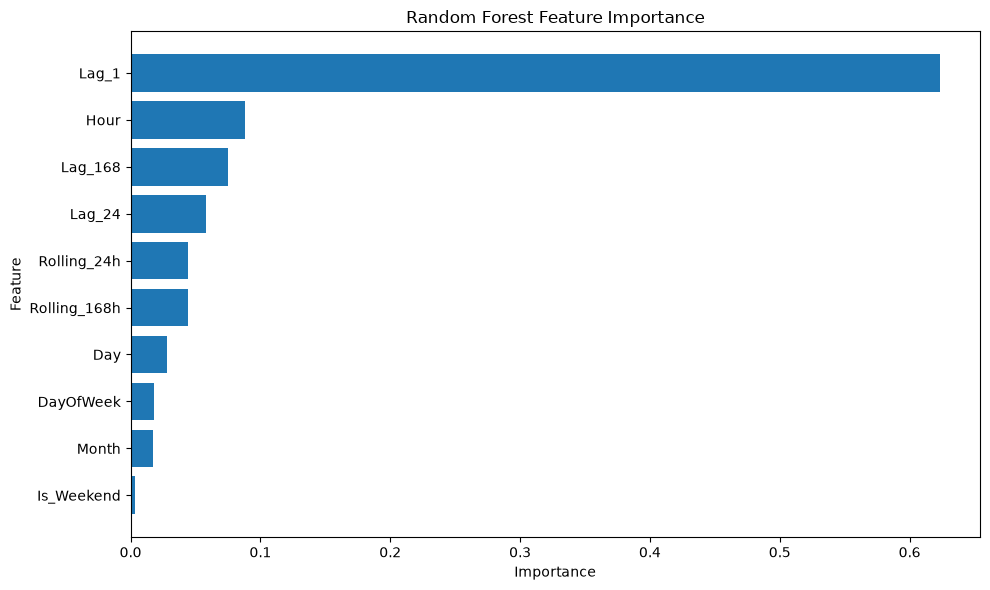

In [48]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [49]:
#Final Model Evaluation

if rf_rmse < linear_rmse:
    best_model = rf_model
    best_predictions = rf_predictions
    best_model_name = "Random Forest"
else:
    best_model = linear_model
    best_predictions = linear_predictions
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest


In [50]:
#Final evaluation

best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("Final Model Performance")
print("-----------------------")
print("Model:", best_model_name)
print("MAE :", round(best_mae, 4))
print("RMSE:", round(best_rmse, 4))
print("R²  :", round(best_r2, 4))

Final Model Performance
-----------------------
Model: Random Forest
MAE : 0.3407
RMSE: 0.4935
R²  : 0.5764


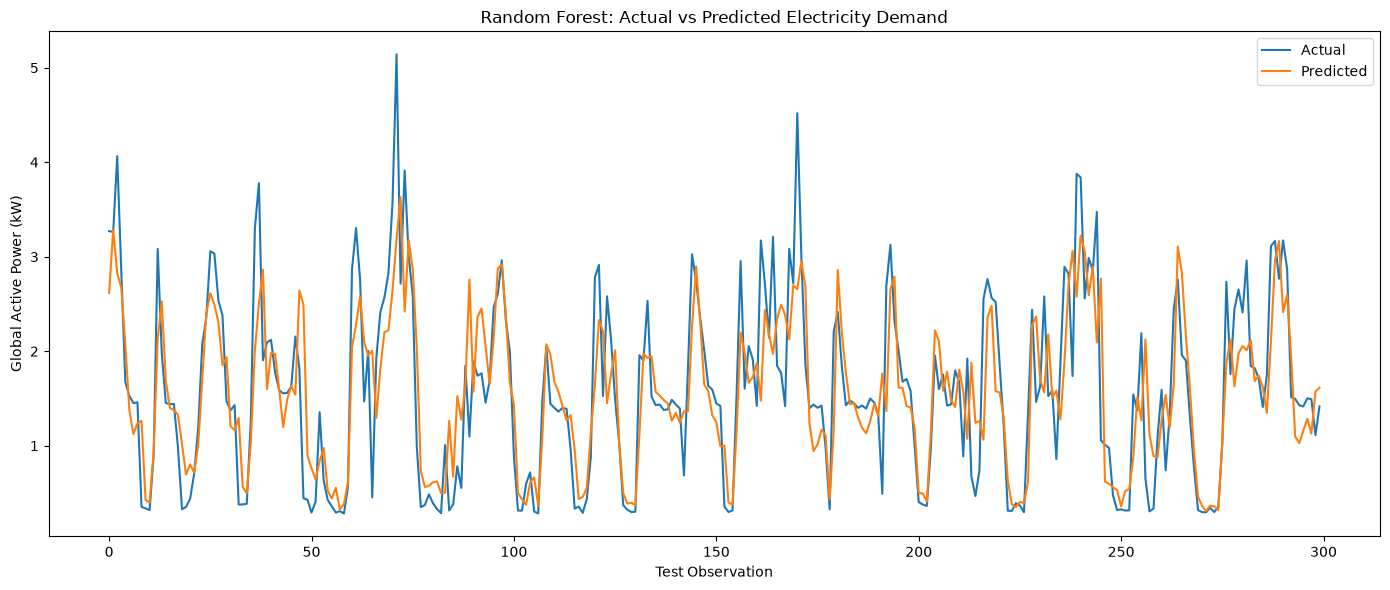

In [51]:


plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    best_predictions[:300],
    label="Predicted"
)

plt.title(
    f"{best_model_name}: Actual vs Predicted Electricity Demand"
)

plt.xlabel("Test Observation")
plt.ylabel("Global Active Power (kW)")
plt.legend()

plt.tight_layout()
plt.show()

In [52]:
#Prediction Error

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

prediction_results["Error"] = (
    prediction_results["Actual"]
    - prediction_results["Predicted"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Error"].abs()
)

prediction_results.head(10)

,Actual,Predicted,Error,Absolute_Error
0,3.271400,2.615397,0.656003,0.656003
1,3.261800,3.285577,-0.023777,0.023777
2,4.064067,2.822748,1.241319,1.241319
3,2.850633,2.671599,0.179034,0.179034
4,1.676300,2.072527,-0.396227,0.396227
5,1.527600,1.376388,0.151212,0.151212
6,1.450533,1.122642,0.327892,0.327892
7,1.459267,1.238242,0.221024,0.221024
8,0.352733,1.263111,-0.910377,0.910377
9,0.336233,0.426280,-0.090047,0.090047


In [53]:
#largest prediction error

largest_errors = prediction_results.nlargest(
    10,
    "Absolute_Error"
)

largest_errors

,Actual,Predicted,Error,Absolute_Error
6384,5.626833,1.822551,3.804283,3.804283
592,5.090800,1.584858,3.505942,3.505942
595,4.638200,1.803498,2.834702,2.834702
6237,4.156567,1.468201,2.688365,2.688365
1306,0.491533,3.039906,-2.548373,2.548373
5990,4.418900,1.874832,2.544068,2.544068
497,4.059933,1.530185,2.529749,2.529749
3500,3.329033,0.889018,2.440015,2.440015
401,3.924133,1.527426,2.396708,2.396708
5592,3.391467,1.060675,2.330791,2.330791
